In [3]:
import numpy as np
import pandas as pd
import sympy as sm
from scipy.stats import gamma

import os
import sys

# Standard interactive replacement for the 'parent directory' hack
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from utils import remove_cycles, mat_from_np, move_scattered_identity
from PPRCalculator import PPRCalculator

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Models

### ToyModel#1Article

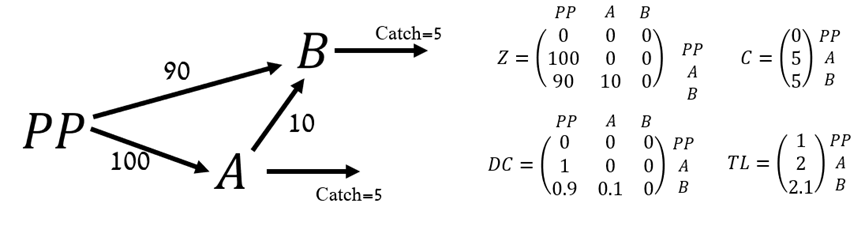

In [4]:
Z = pd.DataFrame({
    0: [0, 0, 0, 0],
    1: [0, 0, 0, 0],
    2: [100, 0, 0, 0],
    3: [90, 0, 10, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A', 
    3: 'B'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A', 'B']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular', 'Regular']
groups_df['q'] = [190, 0, 100, 100]
groups_df['p'] = [190, 0, 15, 5]
groups_df['catch'] = [0, 0, 5, 5]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = 0
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = 0
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

In [14]:
self.is_model_balanced()

(True,
 3      5
 2     15
 1      0
 0    190
 dtype: int64,
 3    100
 2    100
 1      0
 0    190
 dtype: int64)

### SimpleCycle1

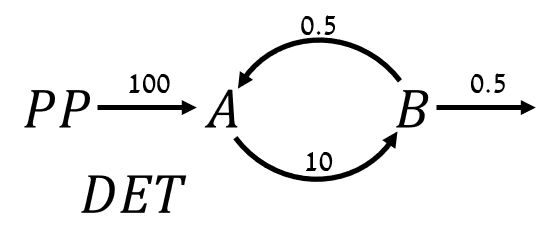

In [2]:
Z = pd.DataFrame({
    0: [0, 0, 0, 0],
    1: [0, 0, 0, 0],
    2: [100, 0, 0, 0.5],
    3: [0, 0, 10, 0]
}).T
DC = Z.div(Z.sum(axis=1), axis='index').fillna(0)
seq2name = {
    0: 'PP',
    1: 'DET',
    2: 'A', 
    3: 'B'
}
name2seq = {v: k for k, v in seq2name.items()}
groups_df = pd.DataFrame()
groups_df['group_name'] = ['PP', 'DET', 'A', 'B']
groups_df['trophic_info'] = ['PP', 'DET', 'Regular', 'Regular']
groups_df['q'] = [100, 0, 100.5, 10]
groups_df['p'] = [100, 0, 10, 1]
groups_df['catch'] = [0, 0, 0, 0.5]
groups_df['predation'] = Z.fillna(0).sum(axis=0).sort_index(ascending=False).copy()
groups_df['biomass_accum'] = 0
groups_df['immigration'] = 0
groups_df['emigration'] = 0
groups_df['net_migration'] = groups_df['emigration'] - groups_df['immigration']
groups_df['M0'] = 0
groups_df['egestion'] = 0
groups_df['respiration'] = groups_df['q'] - (groups_df['p'] + groups_df['egestion'])
groups_df['ee'] = 1 - groups_df['M0'] / groups_df['p']
groups_df['ge'] = groups_df['p'] / groups_df['q']
groups_df['gs'] = groups_df['egestion'] / groups_df['q']

self = PPRCalculator.from_dict({
    '_Z': Z,
    '_DC': DC,
    'seq2name': seq2name,
    'name2seq': name2seq,
    '_groups_df': groups_df,
    'n_groups': groups_df.shape[0],
    'growth': groups_df['biomass_accum']
} | groups_df.rename(columns={'ee': 'EE', 'ge': 'GE', 'gs': 'GS'}).to_dict(orient='series')
)

In [3]:
self.is_model_balanced()

(True,
 3      1.0
 2     10.0
 1      0.0
 0    100.0
 dtype: float64,
 3     10.0
 2    100.5
 1      0.0
 0    100.0
 dtype: float64)

## Calculations

In [5]:
# self.get_TL(break_cycles=True, DET_as_PP=True)
# self.get_TL(break_cycles=False, DET_as_PP=True)
# remove_cycles(self.get_Z(DET_as_PP=True).copy(), new=False)
# self.get_Z(DET_as_PP=True)

In [ ]:
sppr, A, L = self.SPPR_EwE_Ido(TE_option='TE', global_TE='mean', use_EE=True)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr, only_inner=True).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
print(f'PPR/NPP: {self.get_PPR2NPP_ratio(sppr)}')
# sppr.sum(axis=1)
sppr

catch    190.0
dtype: float64


balanced: (True, np.int64(190), np.float64(190.00000000000003))
PPR/NPP: 1.0000000000000002


,DET,PP
B,0.0,31.333333
A,0.0,6.666667
DET,NaN,NaN
PP,0.0,1.000000


In [16]:
sppr, A, L = self.SPPR_new(TE=None, TE_option='TE', DET_TE_vals=1)
sppr, A, L = PPRCalculator.rename_results([sppr, A, L], self.seq2name)
print(self.get_PPR(sppr, only_inner=True).sum(axis=1))
print(f'balanced: {self.is_sppr_balanced(sppr)}')
print(f'PPR/NPP: {self.get_PPR2NPP_ratio(sppr)}')
# sppr.sum(axis=1)
sppr

catch    190.0
dtype: float64
balanced: (True, np.int64(190), np.float64(190.00000000000003))
PPR/NPP: 1.0000000000000002


c:\Users\idoca\Desktop\אישי\אקדמיה\תואר שני\מחקר\BTN\FishEstimation\PPRCalculator.py:497: RuntimeWarning: invalid value encountered in scalar divide
  sppr_det = (self.M0 + self.egestion)[list(self.get_PP_seq() + self.get_Import_seq())].sum() / flow2det


,DET,PP
B,NaN,31.333333
A,NaN,6.666667
DET,NaN,0.000000
PP,NaN,1.000000
